In [1]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

In [2]:
def make_graph(stock_data, revenue_data, stock):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Plot stock price
    ax1.plot(stock_data['Date'], stock_data['Close'], color='blue', label='Stock Price')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Stock Price', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')
    
    # Plot revenue
    ax2 = ax1.twinx()
    ax2.plot(revenue_data['Date'], revenue_data['Revenue'], color='orange', label='Revenue')
    ax2.set_ylabel('Revenue', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.legend(loc='upper right')
    
    plt.title(f'{stock} Stock Price and Revenue Over Time')
    plt.grid(True)
    plt.show()

In [3]:
# Create Ticker object for Tesla (TSLA)
tesla = yf.Ticker("TSLA")

# Get historical data for maximum period
tesla_data = tesla.history(period="max")

# Reset index to have Date as a column
tesla_data.reset_index(inplace=True)

# Display first 5 rows
print(tesla_data.head())

                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  


In [4]:
# URL for Tesla revenue data (from Yahoo Finance)
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"

# Read HTML table
tesla_revenue = pd.read_html(url)[0]

# Clean the data - remove rows with missing values
tesla_revenue = tesla_revenue.dropna()

# Rename columns
tesla_revenue.columns = ['Date', 'Revenue']

# Remove '$' and ',' from Revenue column and convert to numeric
tesla_revenue['Revenue'] = tesla_revenue['Revenue'].str.replace('$', '')
tesla_revenue['Revenue'] = tesla_revenue['Revenue'].str.replace(',', '')
tesla_revenue['Revenue'] = pd.to_numeric(tesla_revenue['Revenue'])

# Display last 5 rows
print(tesla_revenue.tail())

    Date  Revenue
8   2013     2013
9   2012      413
10  2011      204
11  2010      117
12  2009      112


In [5]:
# Create Ticker object for GameStop (GME)
gme = yf.Ticker("GME")

# Get historical data for maximum period
gme_data = gme.history(period="max")

# Reset index to have Date as a column
gme_data.reset_index(inplace=True)

# Display first 5 rows
print(gme_data.head())

                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620129  1.693350  1.603296  1.691667  76216000   
1 2002-02-14 00:00:00-05:00  1.712707  1.716074  1.670626  1.683250  11021600   
2 2002-02-15 00:00:00-05:00  1.683250  1.687458  1.658002  1.674834   8389600   
3 2002-02-19 00:00:00-05:00  1.666417  1.666417  1.578047  1.607504   7410400   
4 2002-02-20 00:00:00-05:00  1.615920  1.662210  1.603296  1.662210   6892800   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  


In [6]:
# URL for GME revenue data
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"

# Read HTML table
gme_revenue = pd.read_html(url)[0]

# Clean the data
gme_revenue = gme_revenue.dropna()
gme_revenue.columns = ['Date', 'Revenue']

# Remove '$' and ',' from Revenue column
gme_revenue['Revenue'] = gme_revenue['Revenue'].str.replace('$', '')
gme_revenue['Revenue'] = gme_revenue['Revenue'].str.replace(',', '')
gme_revenue['Revenue'] = pd.to_numeric(gme_revenue['Revenue'])

# Display last 5 rows
print(gme_revenue.tail())

    Date  Revenue
11  2009     8806
12  2008     7094
13  2007     5319
14  2006     3092
15  2005     1843


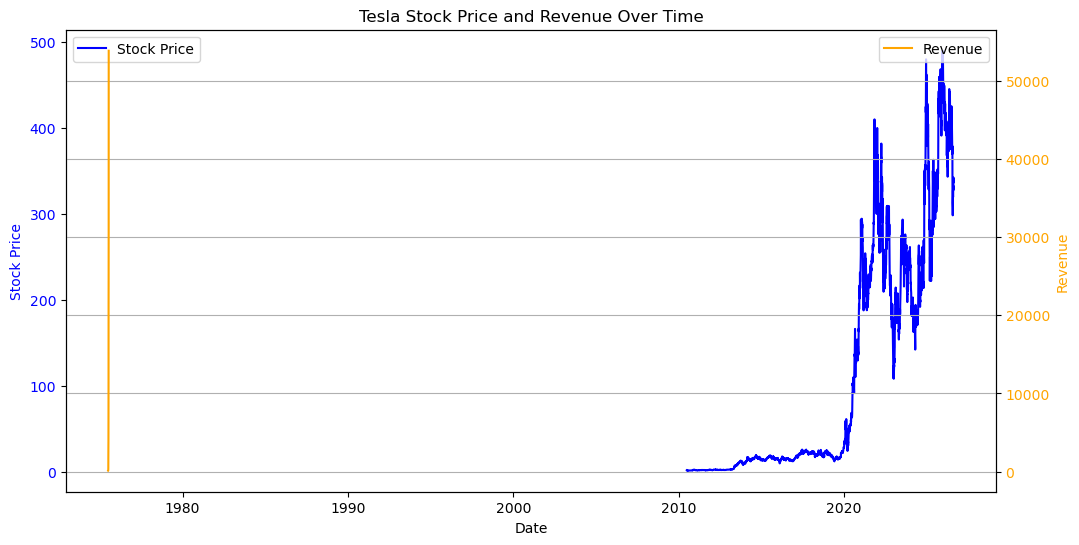

In [7]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

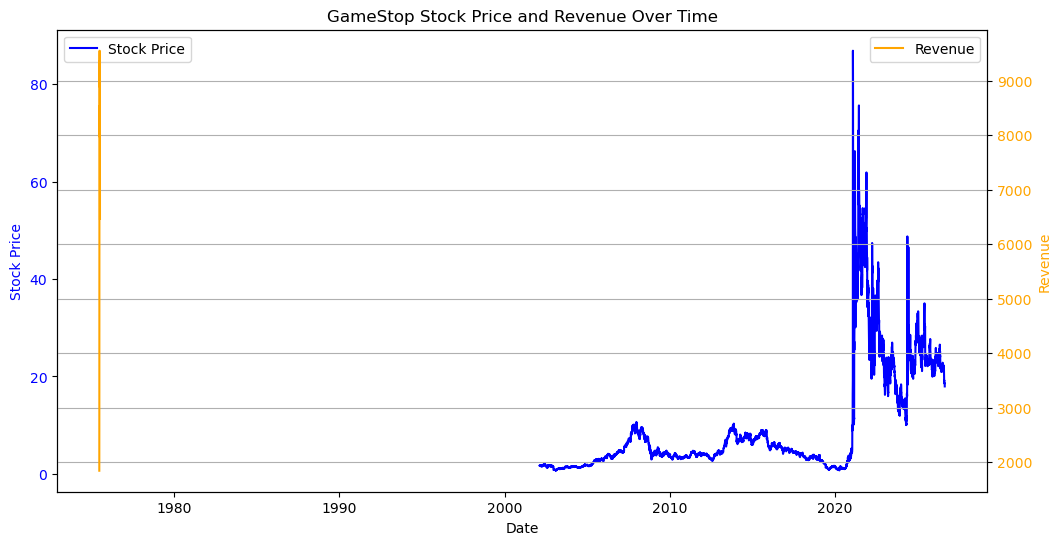

In [8]:
make_graph(gme_data, gme_revenue, 'GameStop')